In [1]:
from glob import glob

from collections import defaultdict
import numpy as np
import json
import pandas as pd
from sewar import msssim
from PIL import Image

from _plotting import plot_tradeoff

%load_ext autoreload
%autoreload 2

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path,

In [32]:
data = pd.read_csv("RQ4_anonymized.csv")

## Get quality data points

In [33]:
data = pd.read_csv("RQ4_anonymized.csv")
data.columns = [c.split(".")[0] if "." in c else c for c in data.columns]  # Allow duplicate column names -> lr config per topic

In [34]:
valid_data = data[data['TAKE'] == 'Y']
print(f"Fraction of Valid Responses: {len(valid_data) / len(data):.2%}")

Fraction of Valid Responses: 71.59%


In [35]:
responses = valid_data["Topic"].value_counts()
print(f"Valid responses per topic: {responses}")
print(f"Mean + std: {responses.mean():.3f} pm {responses.std():.3f}")

Valid responses per topic: Topic
Hen                  10
Tigershark            8
Rooster               8
Pizza                 6
Hammerhead Shark      6
Goldfish              6
Teddy Bear            5
Great White Shark     5
Electric Ray          5
Stingray              4
Name: count, dtype: int64
Mean + std: 6.300 pm 1.829


In [36]:
selected_cols = valid_data.iloc[:, 1:-1]  # Get questions only
lr_map = {c: int(c[0])*10**(-int(c[1])) for c in selected_cols.columns.unique()}  # Remove attention questions (99).
data_map = {v: None for v in lr_map.values()}

for col in selected_cols.columns.unique():
    data_map[lr_map[col]] = selected_cols[col].stack().dropna().tolist()

## Get runtime data points

In [37]:
usr_dir = "/home/weissl"
stats = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep/*_runs/*/*/stats.json")

In [38]:
results = defaultdict(list)
for s in stats:
    key = s.split("_runs")[0].split("/")[-1]
    with open(s, "rb") as f:
        data = json.load(f)
    results[key].append(data["runtime"])

In [39]:
key_map = {float(k.split("_")[0]):k for k in results.keys()}

## Get SSIM data

In [9]:
usr_dir = "/home/weissl"
origins = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_im/*_runs/*/*/origin*.png")
targets = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_im/*_runs/*/*/taget*.png")

In [41]:
ssims = defaultdict(list)
for o, t in zip(origins, targets):
    key = o.split("_runs")[0].split("/")[-1]
    img1 = np.array(Image.open(o).convert("RGB"))
    img2 = np.array(Image.open(t).convert("RGB"))
    ssims[key].append(msssim(img1, img2).real)

## Plot tradeoff

In [42]:
runt = [np.array(results[key_map[kr]]) for kr in sorted(key_map.keys())]
qual = [(np.array(data_map[kq])-1) / 4 for kq in sorted(data_map.keys())]
ssim = [np.array(ssims[key_map[kr]]) for kr in sorted(key_map.keys())]
ticks = [r"$\rightarrow$".join(key_map[kr].split("_")) for kr in sorted(key_map.keys())]

left_m = [(runt, "Runtime (sec)", (0-1250 * 0.01, 1250 * 1.01))]
right_m = [(qual, "Realism", (-0.01, 1.01)), (ssim, "MS-SSIM", (-0.01, 1.01))]

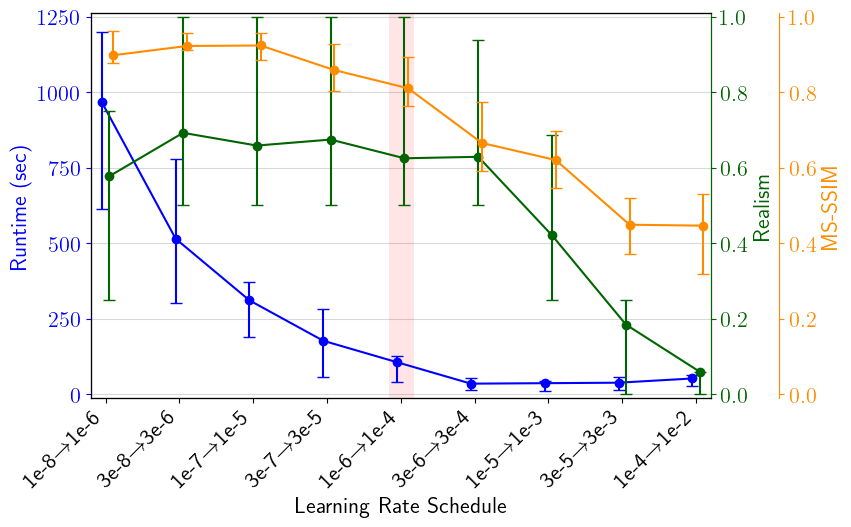

In [43]:
plot_tradeoff(left_m, right_m, ticks, colors=["blue", "darkgreen", "darkorange"], name="ImageNet", vline=4)

### Plot examples

In [47]:
groups = defaultdict(list)
tgts = [t for t in targets if "class_963_" in t]
for path in tgts:
    config = path.split("_runs/")[0].split("/")[-1]
    groups[config].append(path)

examples = {k: v[0] for k, v in groups.items()}
configs = sorted({cfg for cfg in examples.keys()})

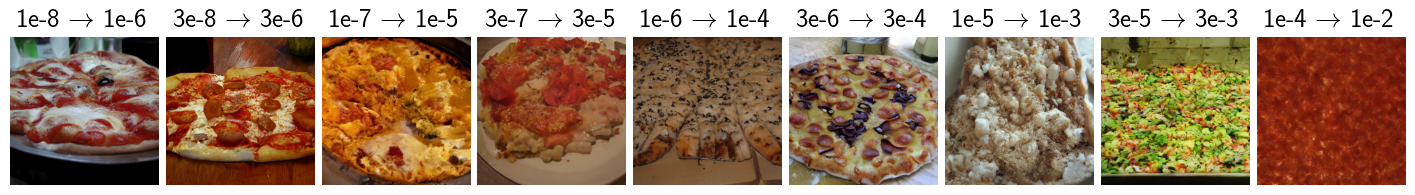

In [68]:
import matplotlib.pyplot as plt

def parse(c):
    a, b = c.split("_")
    return float(a), float(b)

fig, axes = plt.subplots(1,len(configs),figsize=(2 * len(configs), 2.45), gridspec_kw=dict(wspace=0.05, hspace=0.))

for ax, cfg in zip(axes, sorted(configs, key=lambda c: parse(c)[0])):
    path = examples[cfg]
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(r" $\rightarrow$ ".join(cfg.split("_")))
    ax.axis("off")

plt.savefig("figures/RQ4_SweepIN_Examples.pdf", dpi=200, bbox_inches="tight")